In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import re
import json
import pickle
from collections import Counter

In [2]:
class Config:

    num_layers = 1000
    d_model = 1024
    d_ff = 76000000
    num_heads = 4
    max_seq_len = 256
    vocab_size = 8_000
    lr = 3e-4
    
    
    @classmethod
    def neuron_count(cls):
        return cls.num_layers *(cls.d_model+cls.d_ff)

    @classmethod
    def show(cls):
        n= cls.neuron_count()
        print(f"\n{'/'*40}")
        print(f"- layer      { cls.num_layers:>12}")
        print(f"- d_ff       {cls.d_ff:>12}")
        print(f"- d_model      {cls.d_model:>12}")
        print(f"- heads      {cls.num_heads:>12}")
        print(f"- neurons    {n:>12,}   (target 86 B)")
        print(f"- coverage   {n / 86e9 * 100:>11.2f}%")
        print(f"{'/'*40}") 
        

In [ ]:
Config.show()


////////////////////////////////////////
- layer              1000
- d_ff           76000000
- d_model              1024
- heads                 4
- neurons    76,001,024,000   (target 86 B)
- coverage         88.37%
////////////////////////////////////////


In [ ]:
print("Neurons are:",Config.neuron_count())
# 1000*(76000000+10000000)


Neurons are: 76001024000


*Math Utils* 

In [ ]:
def softmax(x,axis = -1):
    e = np.exp(x-x.max(axis = axis,keepdims = True))
    return e/(e.sum(axis= axis,keepdims = True)+1e-9) # softmax = e/sum(e) + h

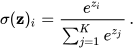 *softmax f(X)*

In [6]:
softmax(np.array([10,100]))

array([8.19401262e-40, 9.99999999e-01])

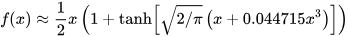 *Guassian error linear unit*

In [7]:
def gelu(x):
    c = math.sqrt(2.0/math.pi)
    return 0.5*x*(1.0+np.tanh(c*(x+0.044715*x**3)))

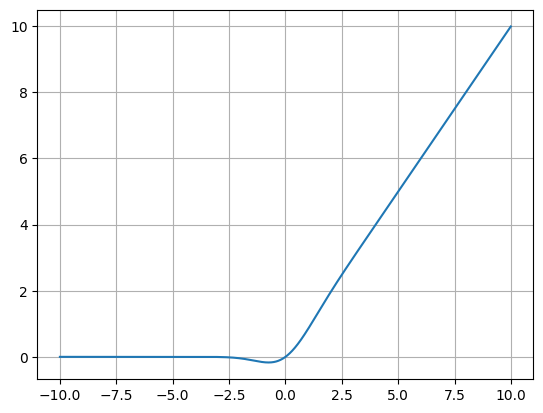

In [8]:
x = np.arange(-10,10,0.01)
y = gelu(x)
plt.plot(x,y)
plt.grid()
# print(x[:10],y[:10])

In [9]:
# y = (x + np.sqrt(x**2+4))/2
# plt.plot(x,y)
# plt.grid() 

In [10]:
def gelu_grad(x):
    c = math.sqrt(2.0/math.pi)
    t = np.tanh(c*(x+0.044715*x**3))
    dt = (1 -t**2)*c*(1.0+3.0*0.044715*x**2)
    return 0.5*(1.0+t)+0.5*x*dt

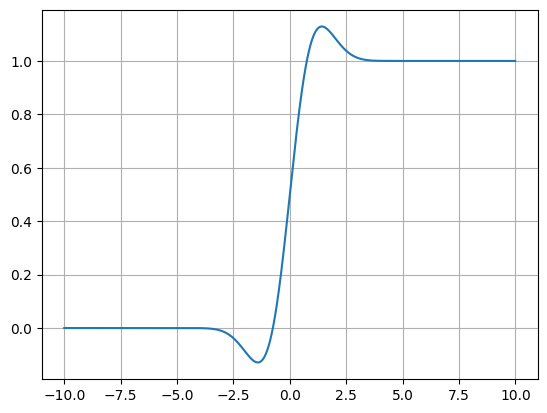

In [11]:
y = gelu_grad(x)
plt.plot(x,y)
plt.grid()

In [12]:
def cosine_sim(a,b):
    return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-9))

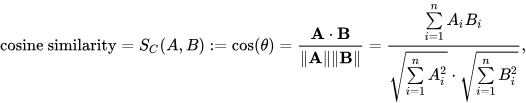

In [13]:
cosine_sim(1,-1)

-0.9999999989999999

In [ ]:
def xavier(rows,cols):
    return (np.random.randn(rows,cols)*math.sqrt(2.0/(rows+cols))).astype(np.float32)

In [15]:
# xavier(2,1)

In [16]:
def cross_entropy(logits,targets):
    B,T,V = logits.shape
    f1 = logits.reshape(-1,V)
    ft  =targets.reshape(-1)
    p = softmax(f1)
    loss = -np.log(p[np.arange(B*T),ft]+1e-9).mean()
    g = p.copy()
    g[np.arange(B*T),ft] -= 1
    g /=(B*T)

    return loss,g.reshape(B,T,V)

In [ ]:
# B,T,V = 2,3,5
# e = np.random.randn(B,T,V)
# f = np.array([[1,4,0],[2,3,1]])
# cross_entropy(e,f)

In [18]:
class LayerNorm:
    def __init__(self,d):
        self.g = np.ones(d,dtype = np.float32)
        self.b = np.zeros(d,dtype = np.float32)
        self.dg = np.zeros_like(self.g)
        self.db = np.zeros_like(self.b)
        self._c = None


    def forward(self,x,eps= 1e-6):
        mu = x.mean(-1,keepdims = True)
        var = ((x -mu)**2).mean(-1,keepdims = True)
        xn = (x - mu )/np.sqrt(var+eps)
        self._c = (xn,var,eps)
        return self.g*xn+self.b

    def backward(self,dy):
        xn = var,eps = self._c
        N = xn.shape[-1]
        self.dg += (dy*xn).reshape(-1,N).sum(0)
        self.db += dy.reshape(-1,N).sum(0)
        dxn = dy * self.g
        dx = (dxn.mean(-1,keepdims = True)-xn*(dxn*xn).mean(-1,keepdims = True))/np.sqrt(var+eps)
        return dx
    def zero_grad(self):self.dg[:]=0;self.db[:]=0
    def upgrade(self,lr): self.g -=lr*self.dg; self.b -=lr*self.db

In [19]:

# ln = LayerNorm(3)
# # print(ln.g,ln.b,ln.dg,ln.db,ln._c)

# x = np.array([[10.,10.,3.],[2.,3.,4.]],dtype = np.float32)
# ln.forward(x)

In [ ]:
class Tokenizer:
    PAD, UNK, BOS, EOS = 0, 1, 2, 3
    _SPECIAL = {"<PAD>": 0, "<UNK>": 1, "<BOS>": 2, "<EOS>": 3}

    def __init__(self, vocab_size=8_000):
        self.vs  = vocab_size
        self.w2i = dict(self._SPECIAL)
        self.i2w = {v: k for k, v in self.w2i.items()}

    @staticmethod
    def _split(text):
        return re.findall(r"\b\w+\b|[^\w\s]", text.lower())

    def build(self, texts):
        freq = Counter(tok for t in texts for tok in self._split(t))
        for w, _ in freq.most_common(self.vs - len(self._SPECIAL)):
            if w not in self.w2i:
                i = len(self.w2i); self.w2i[w] = i; self.i2w[i] = w

    def encode(self, text):
        return ([self.BOS]
                + [self.w2i.get(t, self.UNK) for t in self._split(text)]
                + [self.EOS])

    def decode(self, ids):
        return " ".join(self.i2w.get(i, "<UNK>") for i in ids
                        if i not in self._SPECIAL.values())

    def __len__(self): return len(self.w2i)

In [21]:
class Embedding:
    def __init__(self, vocab, d, max_len):
        self.W   = (np.random.randn(vocab, d) * 0.02).astype(np.float32)
        self.pos = self._sinusoidal(max_len, d)   # fixed, not learned
        self.dW  = np.zeros_like(self.W)
        self._ids = None

    @staticmethod
    def _sinusoidal(L, d):
        
        pe  = np.zeros((L, d), dtype=np.float32)
        pos = np.arange(L)[:, None]
        div = np.exp(np.arange(0, d, 2) * -(math.log(10_000.0) / d))
        pe[:, 0::2] = np.sin(pos * div)
        pe[:, 1::2] = np.cos(pos * div[:pe[:, 1::2].shape[1]])
        return pe

    def forward(self, ids):          # ids : (B, T)
        self._ids = ids
        return self.W[ids] + self.pos[None, :ids.shape[1], :]   # (B, T, d)

    def backward(self, dy):          # dy  : (B, T, d)
        np.add.at(self.dW, self._ids, dy)

    def zero_grad(self): self.dW[:] = 0
    def update(self, lr): self.W -= lr * self.dW

In [22]:
class MultiHeadAttention:
    

    def __init__(self, d, h):
        assert d % h == 0, "d_model must be divisible by num_heads"
        self.d, self.h, self.dk = d, h, d // h
        self.Wq = xavier(d, d); self.dWq = np.zeros_like(self.Wq)
        self.Wk = xavier(d, d); self.dWk = np.zeros_like(self.Wk)
        self.Wv = xavier(d, d); self.dWv = np.zeros_like(self.Wv)
        self.Wo = xavier(d, d); self.dWo = np.zeros_like(self.Wo)
        self._c = None

    def _split(self, x, B):   # (B, T, d) → (B, h, T, dk)
        return x.reshape(B, -1, self.h, self.dk).transpose(0, 2, 1, 3)

    def _join(self, x, B):    # (B, h, T, dk) → (B, T, d)
        return x.transpose(0, 2, 1, 3).reshape(B, -1, self.d)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        Q = self._split(x @ self.Wq, B)   # project and split into heads
        K = self._split(x @ self.Wk, B)
        V = self._split(x @ self.Wv, B)
        # Scaling by 1/√dk prevents softmax saturation for large dk
        S = Q @ K.transpose(0, 1, 3, 2) / math.sqrt(self.dk)  # (B, h, T, T)
        if mask is not None:
            S += mask * -1e9               # future positions → −∞ before softmax
        A = softmax(S, axis=-1)            # attention weights
        C = self._join(A @ V, B)           # context vectors
        self._c = (x, Q, K, V, A, C)
        return C @ self.Wo

    def backward(self, dy):
        x, Q, K, V, A, C = self._c
        B, T, _ = x.shape

        # ① grad through output projection:  out = C @ Wo
        self.dWo += C.reshape(-1, self.d).T @ dy.reshape(-1, self.d)
        dC = self._split(dy @ self.Wo.T, B)          # (B, h, T, dk)

        # ② grad through attention pooling:  C = A @ V
        dA = dC @ V.transpose(0, 1, 3, 2)            # (B, h, T, T)
        dV = A.transpose(0, 1, 3, 2) @ dC            # (B, h, T, dk)

        # ③ grad through softmax:  A = softmax(S)
        #    formula: dS = A ⊙ (dA − rowsum(A·dA))
        dS = A * (dA - (dA * A).sum(-1, keepdims=True))
        dS /= math.sqrt(self.dk)                      # undo the scale

        # ④ grad through score:  S = Q @ Kᵀ
        dQ = dS @ K                                   # (B, h, T, dk)
        dK = dS.transpose(0, 1, 3, 2) @ Q            # (B, h, T, dk)

        # ⑤ merge heads and grad through input projections
        dQ = self._join(dQ, B); dK = self._join(dK, B); dV = self._join(dV, B)
        xf = x.reshape(-1, self.d)
        self.dWq += xf.T @ dQ.reshape(-1, self.d)
        self.dWk += xf.T @ dK.reshape(-1, self.d)
        self.dWv += xf.T @ dV.reshape(-1, self.d)
        return dQ @ self.Wq.T + dK @ self.Wk.T + dV @ self.Wv.T

    def zero_grad(self):
        for dW in (self.dWq, self.dWk, self.dWv, self.dWo): dW[:] = 0

    def update(self, lr):
        for W, dW in ((self.Wq, self.dWq), (self.Wk, self.dWk),
                      (self.Wv, self.dWv), (self.Wo, self.dWo)):
            W -= lr * dW

In [23]:
class FeedForward:
    def __init__(self,d,d_ff):
        self.W1 = xavier(d,d_ff);self.dW1 = np.zeros_like(self.W1)
        self.b1 = np.zeros(d_ff,dtype = np.float32);self.db1 = np.zeros_like(self.b1)
        self.W2 = xavier(d_ff,d);self.dW2 = np.zeros_like(self.W2)
        self.b2 = np.zeros(d,dtype = np.float32);self.db2 = np.zeros_like(self.b2)
        self._c = None

    def forward(self,x):
        pre = x@self.W1 +self.b1
        h =gelu(pre)
        self._c = (x,pre,h)
        return h@ self.W2+self.b2
    def backward(self,dy):
        x,pre,h = self._c
        xf = x.reshape(-1,x.shape[-1])
        hf = h.reshape(-1,h.shape[-1])
        dyf = dy.reshape(-1,dy.shape[-1])
        self.dW2 += hf.T@dyf
        self.db2 += dyf.sum(0)

        dh = dy@ self.W2.T
        dpre = dh*gelu_grad(pre)
        dpref = dpre.reshape(-1,pre.reshape[-1])
        self.dW1 += xf.T@dpref
        self.db1 += dpref.sum(0)

        return dpre@ self.W1.T
    def zero_grad(self):
        for arr in (self.dW1,self.db1,self.dW2,self.db2):arr[:]  = 0
    def update(self,lr):
        self.W1 -= lr*self.dW1;self.b1 -=lr*self.db1
        self.W2-= lr*self.dw2;self.b2 -= lr * self.db2

In [24]:
class Block:
    def __init__(self,d,h,d_ff):
        self.ln1 = LayerNorm(d)
        self.attn = MultiHeadAttention(d,h)
        self.ln2 = LayerNorm(d)
        self.ff = FeedForward(d,d_ff)
        self._c = None
    def forward(self,x,mask = None):
        a  = self.attn.forward(self.ln1.forward(x),mask)
        x1 = x+a
        f = self.ff.forwars(self.ln2.forward(x1))
        x2 = x1+f
        self._c = (x,x1)
        return x2
    def backward(self,dy):
        x,x1 = self._c
        dff = self.ff.backward(dy)
        dx1 = dy+self.ln2.backward(dff)
        dattn = self.attn.backward(dx1)
        dx = dx1 +self.ln1.backward(dattn)
        return dx
    def zero_grad(self):
        self.ln1.zeros_grad();self.attn.zero_grad()
        self.ln2.zero_grad();self.ff.zero_grad()
    def update(self,lr):
        self.ln1.update(lr);self.attn.update(lr)
        self.ln2.update(lr);self.ff.update(lr)
            

In [ ]:
class LM:
    def __init__(self,cfg:Config):
        self.cfg = cfg
        self.emb = Embedding(cfg.vocab_size,cfg.d_model,cfg.max_seq_len)
        self.blocks = [Block(cfg.d_model,cfg.num_heads,cfg.d_ff)
                       for _ in range(cfg.num_layers)]
        self.ln_f = LayerNorm(cfg.d_model)
        self.proj = xavier(cfg.d_model,cfg.vocab_size)
        self.dproj = np.zeros_like(self.proj)
        self.losses = []
        self._x = None
    @staticmethod
    def _causal_mask(T):
        return np.triu(np.ones((1,1,T,T),dtype = np.flaot32),k=1)
    def forward(self,ids):
        x = self.emb.forward(ids)
        mask = self._causal_mask(ids.shape[1])
        for blk in self.blocks:
            x = blk.forward(x,mask)
        x = self.ln_f.forward(x)
        self._x =x
        return x@ self.proj
    def backward(self,dlogits):
        self.dproj += (self._x.reshape(-1,self.cfg.d_model).T
                       @ dlogits.reshape(-1,self.cfg.vocab_size))
        dx = dlogits@self.proj.T
        dx = self.ln_f.backward(dx)
        for blk in reversed(self.blocks):
            dx = blk.backward(dx)
        self.emb.backward(dx)
    def zero_grad(self):
        self.dproj[:]= 0
        self.emb.zero_grad();self.ln_f.zero_grad()
        for blk in self.blocks:blk.zero_grad()

    def update(self,lr):
        self.proj -= lr*self.dproj
        self.emb.update(lr);self.ln_f.update(lr)
        for blk in self.blocks:blk.update(lr)
    def _clip_grads(self,max_norm=1):
        grads = ([self.dproj,self.emb.dW,self.ln_f.dg,self.ln_f.db]+
                 [g for blk in self.blocks
                  for g in (blk.attn.dWq,blk.attn.dWk,blk.attn.dWv,blk.attn.dWo,
                            blk.ff.dw1,blk.ff.dW2,blk.ff.db1,blk.ff.db2,
                            blk.ln1.dg,blk.ln1.db,blk.ln2.dg,blk.ln2.db)])
        total = math.sqrt(sum(float(np.sum(g**2))for g in grads))
        if total> max_norm:
            scale = max_norm/total
            for g in grads: g*= scale
    def train_step(self,ids):
        inp = ids[:,:-1]
        tgt = ids[:,1:]
        logits = self.forward(inp)
        loss,dlogits = cross_entropy(logits,tgt)
        self.zero_grad()
        self.backward(dlogits)
        self._clip_grads(max_norm = 1)
        self.update(self.cfg.lr)
        self.losses.append(float(loss))
        return float(loss)


    def generate(self,seed_ids,max_new = 80,temperature =0.8,top_k = 40):
        ids = list(seed_ids)
        for _ in range(max_new):
            ctx = np.array([ids[-self.cfg.max_seq_len:]])
            lg = self.forward(ctx)[0,-1,:]/temperature 
            if top_k and top_k < len(lg):
                cutoff = np.sort(lg)[-top_k]
                lg = np.where(lg>=cutoff,lg,-1e9)
            probs = softmax(lg)
            nxt = int(np.random.choice(len(probs),p= probs))
            ids.append(nxt)
            if nxt == Tokenizer.EOS:break
        return ids

    def save(self,path = "lm.pkl"):
        with open(path,'wb') as f:pickle.dump(self,f)

    @staticmethod
    def load(path="lm.pkl"):
        with open(path,'rb') as f: return pickle.load(f)
       

In [ ]:
class VectorStore:


    def __init__(self):
        self.docs =[]; self.vec = []
    def add(self,text,vec):
        self.vecs.append(vec/(np.linalg.norm(vec)+1e-9))
        self.docs.append(text)
    def search(self,q,k = 3):
        if not self.vecs: return []
        q = q/(np.linalg.norm(q)+1e-9)
        scores = [float(np.dot(q,v)) for v in self.vecs]
        top = sorted(range(len(scores)),key = lambda i :-scores[i])[:k]
        return [(self.docs[i],scores[i]) for i in top]
    def __len__(self):
        return len(self.docs)


In [27]:
class RAG:
    """
    Retrieval-Augmented Generation.
      add(text)          → chunk → embed → VectorStore
      retrieve(query)    → embed query → cosine search → top-k chunks
      answer(question)   → retrieve context → [ctx | q] → LM.generate()
      train_on_docs()    → fine-tune LM on all indexed documents
    """

    def __init__(self, lm: LM, tok: Tokenizer):
        self.lm    = lm
        self.tok   = tok
        self.store = VectorStore()
        self._docs = []                      # fix: was self._dics

    def _embed(self, text):
        """Mean-pool token embeddings — fast retrieval proxy."""
        ids = self.tok.encode(text)[:self.lm.cfg.max_seq_len]
        return self.lm.emb.W[ids].mean(0)

    def add(self, text, chunk_words=50, overlap=10):
        """Split doc into overlapping word windows; embed + index each chunk."""
        words = text.split()
        step  = max(1, chunk_words - overlap)
        for i in range(0, max(1, len(words) - chunk_words + 1), step):
            chunk = " ".join(words[i: i + chunk_words])
            self.store.add(chunk, self._embed(chunk))
        self._docs.append(text)              # fix: was self._dics

    def retrieve(self, query, k=3):
        return self.store.search(self._embed(query), k)

    def answer(self, question, k=3, max_new=60, temperature=0.7):
        """Retrieve top-k chunks, prepend as context, generate answer."""
        hits   = self.retrieve(question, k)
        ctx    = " | ".join(doc for doc, _ in hits)
        prompt = f"context : {ctx} question : {question} answer :"
        ids    = self.tok.encode(prompt)[:self.lm.cfg.max_seq_len - max_new]
        gen    = self.lm.generate(ids, max_new, temperature)
        return self.tok.decode(gen[len(ids):])

    def train_on_docs(self, epochs=3, verbose=True):
        """Fine-tune the LM on every indexed document (more data = better)."""
        if not self._docs:
            print("No documents added yet."); return
        T = self.lm.cfg.max_seq_len + 1
        for ep in range(epochs):
            losses = []
            for doc in self._docs:
                ids = self.tok.encode(doc)
                for s in range(0, max(1, len(ids) - T), max(1, T // 2)):
                    chunk = np.array([ids[s: s + T]], dtype=np.int32)
                    if chunk.shape[1] < 2: continue
                    losses.append(self.lm.train_step(chunk))  # fix: was trian_step
            if verbose and losses:
                print(f"  epoch {ep+1}/{epochs}  loss = {np.mean(losses):.4f}")

print("RAG (corrected) defined.")

RAG (corrected) defined.


In [28]:
class Visualizer:
    @staticmethod
    def loss_curve(losses):
        if not losses : return
        fig,ax = plt.subplots(figsize= (9,4))
        ax.plot(losses,lw =1.5,color = "#419481")
        ax.set_xlabel("Training step "); ax.set_ylabel("Cross-entropy loss")
        ax.set_title("LM Training loss"); ax.grid(alpha= 0.3)
        fig.tight_layout(); plt.show()

    def architecture(cfg:Config):
        x = np.arange(cfg.num_layers)
        fig,ax = plt.subplots(figsize = (10,4))
        ax.bar(x,[cfg.d_ff]* cfg.num_layers,
               bottom = [cfg.d_model]* cfg.num_layers,
               label = f"FF neurons (d_ff = {cfg.d_ff})",color = '#DD8452')
        ax.set_xlabel("Layer");ax.set_ylabel("Neurons")
        ax.set_title(f"Neuron layout -{cfg.neuron_count():,} total neurons")
        ax.legends(); fig.tight_layout(); plt.show()

    @staticmethod
    def embedding_2d(emb_W,w2i,words):
        present = [w for w in words if w in w2i]
        if len(present)<3:
            print("need > 3 vocab words words for PCA scatter");return 
        E = np.array([emb_W[w2i[w]]for w in present],dtype = float)
        E -= E.mean(0)
        _,vecs = np.linalg.eigh(E.T@E /max (len(E),1))
        proj = E@ vecs [:,-2:]
        fig,ax = plt.subplots(figsize =(8,6))
        ax.scatter(proj[:,0],proj[:,1],s = 60,alpha =0.8,color ="#1CB3E0")
        for i,w in enumerate(present):
            ax.annotate(w,proj[i],fontsize = 9,alpha = 0.9)
        ax.set_title("token embeddings -PCA (2d)"); fig.tight_layout(); plt.show()

    @staticmethod
    def retrieval_bar(hits,query):
        if not hits: return 
        fig ,ax  = plt.subplots(figsize = (8,max(2,len(hits))))
        labels = [f"chunk {i}" for i in range(len(hits))]
        scores = [s for _,s in hits ]
        ax.brah(labels,scores,color = "#301769")
        ax.set_xlabel("Cosine sim")
        ax.set_title(f"retrival scores - '{query[:50]}'")
        fig.tight_layout();plt.show()

    @staticmethod
    def attention_map(attn_weights, tokens):
            """Visualise one (T,T) attention matrix (pass a captured A array)."""
            fig, ax = plt.subplots(figsize=(8, 6))
            im = ax.imshow(attn_weights, cmap="Blues", vmin=0, vmax=1)
            ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=45, ha="right")
            ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
            plt.colorbar(im, ax=ax); ax.set_title("Attention weights")
            fig.tight_layout(); plt.show()


  

    

In [ ]:
# pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.1/378.1 kB 22.5 MB/s eta 0:00:00


In [31]:
import pypdf
import os

In [32]:
# class PDFLoader:

#     @staticmethod
#     def extract_text(pdf_path):
#         reader = pypdf.Pdfreader(pdf_path)
#         pages =[]
#         for page in reader.pages :
#             text = page.extract_text()
#             if text:
#                 pages.append(text)
#         return "\n".join(pages)
#     @staticmethod
#     def clean(text):
#         text = re.sub(r'[^\x20-\x7E\n]', ' ', text)   
#         text = re.sub(r'[ \t]+', ' ', text)              
#         text = re.sub(r'\n{3,}', '\n\n', text)          
#         return text.strip()

#     @staticmethod
#     def load_folder(cls,folder_path,verbose = True):
#         if not os.path.isdir(folder_path):
#             raise FileNotFoundError(f" Folder Not Found:{folder_path}")


#         pdf_files = sorted(f for f in os.listdir(folder_path)
#                             if f.lower().endswith(".pdf"))

#         if not pdf_files:
#             print(f"No .pdf files found in '{folder_path}'")

#         results = []
#         for fname in pdf_files:
#             path = os.path.join(folder_path,fname)
#             try:
#                 raw = cls.extract_text(path)
#                 text  = cls.clean(raw)
#                 if len(text.split())<20:
#                     print(f"SKIP {fname} (too little tet - possibly scanned img)")
#                     continue
#                 results.append((fname,text))
#                 if verbose:
#                     pages = len(pypdf.PdfReader(path).pages)
#                     print(f"Ok {fname}"
#                           f"({pages}page{'s' if pages!= 1 else ''},"
#                           f"{len(text.split()):,} words)")
#             except pypdf.error.PdfStreamError:
#                 print(f"Err {fname} (corrupt or encrypted pdf)")
#             except Exception as e:
#                 print(f"Err {fname} ({e})")

#         print(f"loaded {len(results)}/{len(pdf_files)} Pdf success")
#         return results




In [33]:
class PDFLoader:

    @staticmethod
    def extract_text(pdf_path):
        reader = pypdf.PdfReader(pdf_path)  # Fixed capitalization: PdfReader
        pages = []
        for page in reader.pages:
            text = page.extract_text()
            if text:
                pages.append(text)
        return "\n".join(pages)

    @staticmethod
    def clean(text):
        text = re.sub(r"[^\x20-\x7E\n]", " ", text)
        text = re.sub(r"[ \t]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        return text.strip()

    @classmethod  # Changed from @staticmethod to @classmethod so 'cls' is automatically passed
    def load_folder(cls, folder_path, verbose=True):
        if not os.path.isdir(folder_path):
            raise FileNotFoundError(f"Folder Not Found: {folder_path}")

        pdf_files = sorted(
            f for f in os.listdir(folder_path) if f.lower().endswith(".pdf")
        )

        if not pdf_files:
            print(f"No .pdf files found in '{folder_path}'")

        results = []
        for fname in pdf_files:
            path = os.path.join(folder_path, fname)
            try:
                raw = cls.extract_text(path)
                text = cls.clean(raw)
                if len(text.split()) < 20:
                    print(
                        f"SKIP {fname} (too little text - possibly scanned image)"
                    )
                    continue
                results.append((fname, text))
                if verbose:
                    pages = len(pypdf.PdfReader(path).pages)
                    print(
                        f"Ok {fname} "
                        f"({pages} page{'s' if pages != 1 else ''}, "
                        f"{len(text.split()):,} words)"
                    )
            except pypdf.errors.PdfStreamError:
                print(f"Err {fname} (corrupt or encrypted pdf)")
            except Exception as e:
                print(f"Err {fname} ({e})")

        print(f"Loaded {len(results)}/{len(pdf_files)} PDF success")
        return results

In [34]:
def build_rag(folder_path,epochs = 30,lr = 2e-2,chunk_words = 80,overlap = 15,verbose =True):

    pdf_docs = PDFLoader.load_folder(folder_path,verbose= True)
    if not pdf_docs:
        raise ValueError("No readable PDFs")
    texts = [t for _, t in pdf_docs]
    total_words = sum(len(t.split()) for t in texts)
    print(f"Total corpus:{total_words:,} word across {len(pdf_docs)} files(s)\n")

    print("////// Building vocabulary //////")
    cfg = Config()

    tok = Tokenizer(cfg.vocab_size)
    tok.build(texts)
    cfg.vocab_size = len(tok)
    cfg.lr = lr
    cfg.show()

    print(f"Vocanulary : {len(tok):,} unique tokens\n")

    lm = LM(cfg)
    rag = RAG(lm,tok)

    print("Indexing PDF chinks into Vectorstore ........")
    for fname,text in pdf_docs:
        before = len(rag.store)
        rag.add(text,chunk_words = chunk_words,overlap = overlap)
        added = len(rag.store) - before
        if verbose:
            print(f"{fname} +  {added} chunks (total{len(rag.store)})")
    print()

    print(f"Training LM on PDF Corpus({epochs} epochs) ....")
    rag.train_on_docs(epochs= epochs,verbose = verbose)

    file_list = [fname for fname, _ in pdf_docs]
    return rag,tok,cfg,file_list



In [35]:
PDF_FOLDER = "pdfolder"


if not os.path.isdir(PDF_FOLDER):
    os.makedirs(PDF_FOLDER)
    print(f"created a folder")
    print(f"Drop your pdf files there and rerun")
else :
    pdf_count = len([f for f in os.listdir(PDF_FOLDER) if f.endswith(".pdf")])
    print(f"Found {pdf_count} PDF(s) in '{PDF_FOLDER}'")
    if pdf_count == 0 :
        print("add PDF files to the folder, then run the next cell.")
        




created a folder
Drop your pdf files there and rerun


In [36]:
rag, tok, cfg, files = build_rag(
    PDF_FOLDER,
    epochs     = 30,      
    lr         = 2e-2,
    chunk_words= 80,      
    overlap    = 15,      
)

print(f"\n{'='*50}")
print(f"  PDFs loaded   : {len(files)}")
print(f"  Chunks indexed: {len(rag.store)}")
print(f"  Vocab size    : {len(tok):,}")
print(f"  Loss (final)  : {rag.lm.losses[-1]:.4f}")
print(f"{'='*50}")

No .pdf files found in 'pdfolder'
Loaded 0/0 PDF success


ValueError: No readable PDFs

In [ ]:
viz = Visualizer()
viz.loss_curve(rag.lm.losses)


In [ ]:
viz .architecture(cfg)

In [ ]:
probe_words = list(tok.w2i.keys())[4:24]
viz.embedding_2d(rag.lm.emb.W,tok.w2i,probe_words)

In [ ]:
questions = ["who is Mr. Kalish?"]

for q in questions:
    hits = rag.retrieve(q,k=3)
    print(f"\nQ: {q}")
    viz.retrieve_bar(hits,q)
    for i,(chunk,score) in enumerate(hits):
        print(f"[{score:.3f}]{chunk[:120]}...")
        
